PROCESSAMENTO DADOS PROJETO

In [70]:
from joblib import load, dump
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from util import utils as ut
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier

import os
try:
    os.chdir("./aulas_teoricas")
except FileNotFoundError:
    pass


In [71]:
import os

In [72]:
#os.chdir('aulas_teoricas')

In [73]:
os.listdir()

['00-divisão_dados_2026-07-14.ipynb',
 '01-aula-02_objetivos_2026-07-14.ipynb',
 '02-aula-04_aquisição_2026-07-14.ipynb',
 '03-aula-05_01-dados_2026-07-14.ipynb',
 '03-aula-05_02-cluster_2026-07-14.ipynb',
 '03-aula-05_03-classif_2026-07-14.ipynb',
 '03-aula-05_04-regressão_2026-07-14.ipynb',
 '03-aula-05_05_analise_2026-07-14.ipynb',
 '04-aula-06-divisão de dados_2026-07-14.ipynb',
 '05-aula-07-estruturação_2025-12-03.ipynb',
 '07-aula-09-01-treinamento_feat_selection_2026-07-26.ipynb',
 '07-aula-09-02-treinamento_cluster_2026-07-26.ipynb',
 '07-aula-09-03-treinamento_classif_2026-07-28.ipynb',
 '07-aula-09-04-treinamento_regressão_2026-07-28.ipynb',
 'data',
 'df_projeto_sem_nan',
 'SMOTE.ipynb',
 'src',
 'ydata-profiling.ipynb']

# Importando dataframe de trabalho - 07-df-projeto


In [74]:
from joblib import dump, load

Carregamos a dataframe bruta do projeto 

In [75]:
# dump(df, "./data/07_aula_07_df_projeto")

df_projeto = load("./data/07_aula_07_df_projeto")
df_projeto.head()

,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,...,IgA_2,IgM,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe
0,0.119362,True,True,0.471228,0.398837,0.233216,0.329756,0.417118,True,True,...,Alto,Alto,247.894093,396.067195,0.967908,93,230,42,Normal,leucemia
1,0.112420,True,True,0.292042,0.370941,0.253135,0.340733,0.350616,True,True,...,Alto,Alto,213.416161,361.036864,0.972741,135,351,64,Normal,leucemia
2,0.175636,True,True,0.372872,0.257518,0.451758,0.487803,0.399385,True,True,...,Alto,Alto,296.635039,244.867766,0.971384,69,238,44,Normal,leucemia
3,0.078518,True,True,0.469943,0.495637,0.351360,0.332752,0.487439,True,True,...,Alto,Alto,564.401375,530.296010,0.962450,90,262,41,Normal,leucemia
4,0.061083,True,True,0.349343,0.381742,0.220939,0.479723,0.453555,True,True,...,Alto,Alto,238.791009,152.442218,0.955740,76,209,46,Normal,leucemia


A buscar as informações da df usando _.info()_, fica claro que temos 38 colunas ao total, sendo que as colunas 11 - 14 e 16 parecem ter alguns erros (contagem diferente de 1000). Notamos também que os dados possuem diferentes formatos.

In [76]:
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     956 non-null    float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       916 non-null    float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

Neste momento, aplicamos o data profiling em um script do Google Colaboratory para evitar conflitos de versão das dependências

In [77]:
# Verificando valores faltantes  = CD3_1 com 44 e PPD com 84
df_projeto.isna().sum()

CD34         0
TdT          0
MPO          0
CD19_1       0
CD20_1       0
CD22         0
CD3_1       44
CD7          0
BCR-ABL      0
PML-RARA     0
NMP22        0
BTA         35
hTERT       46
uCyt+       29
FGFR3       70
TP53         0
PPD         84
IFN-γ        0
IL-2         0
TNF-α        0
Th1          0
IgG_1        0
IgA_1        0
CD3_2        0
CD4          0
CD8          0
CD19_2       0
CD20_2       0
IgA_2        0
IgM          0
CD16         0
CD56         0
DHR          0
CH50         0
C3           0
C4           0
FOXP3        0
classe       0
dtype: int64

Ao observar o relatório de pré-processamento, nota-se que ele indica 308 dados faltantes ao inves dos 44+84 indicados pelo isna()

In [78]:
import numpy as np

In [79]:
# Quantificando as entradas na variável CD3_1
df_projeto.CD3_1.value_counts().info()

<class 'pandas.core.series.Series'>
Float64Index: 293 entries, 0.4576626258728855 to 0.1446090250395423
Series name: CD3_1
Non-Null Count  Dtype
--------------  -----
293 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


Apesar de isna() relatar 44 NaNs nesta variavel, value_counts nao detecta a ausencia

In [80]:
df_projeto['CD3_1'].unique

<bound method Series.unique of 0      0.329756
1      0.340733
2      0.487803
3      0.332752
4      0.479723
         ...   
995    0.492897
996    0.184222
997    0.457663
998         NaN
999    0.134253
Name: CD3_1, Length: 1000, dtype: float64>

In [81]:
df_projeto['CD3_1'].dtype

dtype('float64')

Trocando eventuais NaN em string para NaN verdadeiro (numpy)

In [82]:
df_projeto.CD3_1 = df_projeto.CD3_1.replace("NaN", np.nan)


In [83]:
df_projeto.CD3_1.unique()

array([0.32975614, 0.34073307, 0.48780308, 0.33275179, 0.47972311,
       0.31482504, 0.31039059, 0.45405795, 0.31473674, 0.48867835,
       0.34617136, 0.37990772, 0.4429886 , 0.44294606, 0.33005125,
       0.41686913, 0.33887735, 0.42811693, 0.48838643, 0.41667878,
       0.39904932, 0.38790484, 0.35140992, 0.39515371, 0.43786653,
       0.41649522, 0.3195212 , 0.39098828, 0.45766263, 0.35525904,
       0.43164219, 0.43093005, 0.34372056, 0.44407768, 0.47956534,
       0.38885891, 0.47777583, 0.31021277, 0.3637659 , 0.47695168,
       0.3993165 , 0.43081233, 0.40959169, 0.46819387, 0.35803334,
       0.3163067 , 0.33731807, 0.3371146 , 0.42584018, 0.35211967,
       0.46477425, 0.33754159, 0.31467956, 0.44354687, 0.45641995,
       0.35327214, 0.48207228, 0.45953059, 0.47732136, 0.43836415,
       0.34873512, 0.40690369, 0.3771676 , 0.42735114, 0.32229965,
       0.3921511 , 0.384274  , 0.49834146, 0.46883704, 0.42337352,
       0.46190206, 0.46564059, 0.46905971, 0.36901044, 0.32028

Retirando o 'nan' que resta

In [84]:
df_projeto.CD3_1 = df_projeto.CD3_1.replace("nan", np.nan)

In [85]:
# Selecionando entradas com "nan" em CD3_1 -> não restaram nan string
df_projeto[df_projeto.CD3_1 == "nan"].head()

,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,...,IgA_2,IgM,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe


Fazendo o mesmo para a variável PPD, que o relatório indicou com células missing

In [86]:
df_projeto.PPD = df_projeto.PPD.replace("nan", np.nan)
df_projeto.PPD = df_projeto.PPD.replace("NaN", np.nan)

In [87]:
# Veririfcando as informações da df
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     956 non-null    float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       916 non-null    float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

Agora faremos o preenchimento dos NaNs com a media dos dados das variáveis PPD e CD3_1

In [88]:
# Preenchendo valores faltantes com a mediana
df_projeto.PPD.fillna(np.mean(df_projeto.PPD.dropna()), inplace=True)
df_projeto.CD3_1.fillna(np.mean(df_projeto.CD3_1.dropna()), inplace=True)



In [89]:
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     1000 non-null   float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       1000 non-null   float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

# Verificando as variáveis

## Checando constantes

Retorna as categorias de cada variavel

In [90]:
df_projeto.select_dtypes(include='object' ).value_counts().to_frame()


0
BTA   hTERT uCyt+ FGFR3  IL-2  TNF-α IgG_1 IgA_1 IgA_2 IgM   FOXP3    classe               
False False False Normal Baixo Baixo Alto  Baixo Alto  Alto  Normal   cancer            237
                         Alto  Alto  Alto  Alto  Alto  Alto  Normal   BCG               229
                         Baixo Baixo Baixo Baixo Baixo Baixo Alterado imunodeficiencia  196
                                     Alto  Baixo Alto  Alto  Normal   leucemia          174

Nota-se que BTA, hTERT, uCyt+ e FGFR3 são constantes, e portanto, nãi informativas. Por isso, faremos a deleção dessas colunas.

In [91]:

df_projeto.drop(columns=[ 'BTA','hTERT', 'FGFR3', 'uCyt+'], axis=0, inplace=True)


In [92]:
#dataframe sem constantes!
df_projeto.select_dtypes(include='object' ).value_counts().to_frame()

0
IL-2  TNF-α IgG_1 IgA_1 IgA_2 IgM   FOXP3    classe               
Baixo Baixo Alto  Baixo Alto  Alto  Normal   cancer            269
Alto  Alto  Alto  Alto  Alto  Alto  Normal   BCG               264
Baixo Baixo Baixo Baixo Baixo Baixo Alterado imunodeficiencia  240
            Alto  Baixo Alto  Alto  Normal   leucemia          227

Aplico este arquivo no script y_data_profiling_SofiaFeronato.ipynb, e ele nos retorna agora  a ausencia total de arquivos faltantes ou constantes, restanto apenas casos de variáveis altamente correlacionadas


In [93]:
teste_sem_nan = dump(df_projeto, './df_projeto_sem_nan')

Alem de valores faltantes, temos uma distribuicao de cauda longa, que podem tendenciar seu aprendizado. Obsservando o relatório, podemos aplicar essas transformações em CD34, PPD e DHR

Podemos aplicar algumas transformacoes para esse dado.
Normalizar - media da amplitude
Logaritmo - alterar a escala
Exponencial
Padronizar  - tornar media o e desvio 1

> CD34

In [94]:
import matplotlib.pyplot as plt

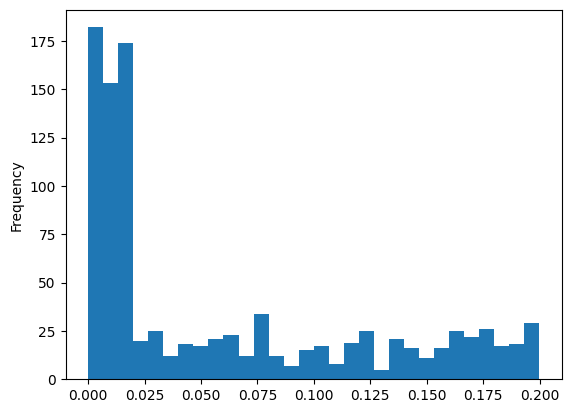

In [95]:
# Dados sem tratamento
df_projeto['CD34'].plot(kind='hist', bins=30)
plt.show()

Dados com transformação logaritmica para CD34

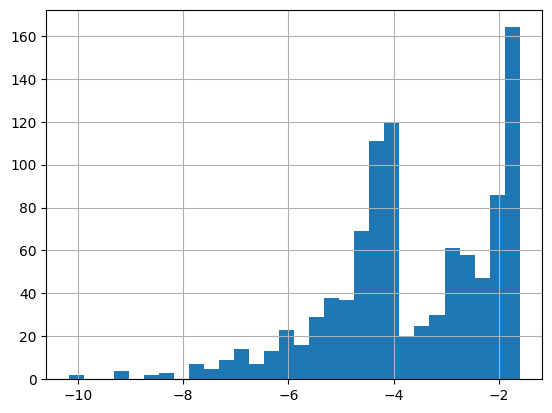

In [96]:
# Dados com transformação logaritmica para CD34
np.log(df_projeto['CD34']).hist(bins=30)
plt.show()

In [97]:
df_projeto['CD34'].describe()

count    1000.000000
mean        0.060034
std         0.063964
min         0.000038
25%         0.010408
50%         0.019465
75%         0.112731
max         0.199757
Name: CD34, dtype: float64

In [98]:
df_projeto['CD34'+'_log'] = np.log(df_projeto['CD34'])
df_projeto.drop('CD34', axis=1, inplace=True)

In [99]:
df_projeto.columns

Index(['TdT', 'MPO', 'CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'BCR-ABL',
       'PML-RARA', 'NMP22', 'TP53', 'PPD', 'IFN-γ', 'IL-2', 'TNF-α', 'Th1',
       'IgG_1', 'IgA_1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'IgA_2',
       'IgM', 'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'FOXP3', 'classe',
       'CD34_log'],
      dtype='object')

Aplicando o mesmo processo para as outras 2 variáveis com cauda longa

> PPD

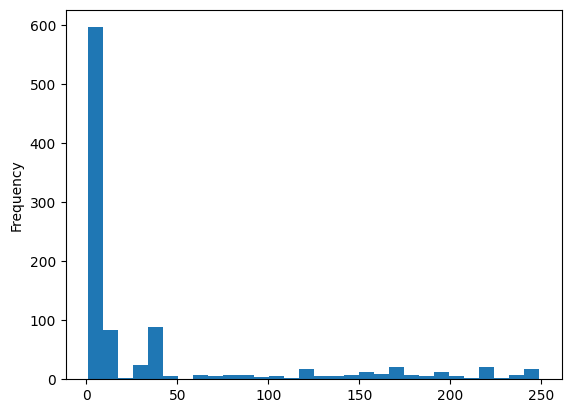

In [100]:
# Dados sem tratamento
df_projeto['PPD'].plot(kind='hist', bins=30)
plt.show()

Dados com transformação logaritmica para PPD


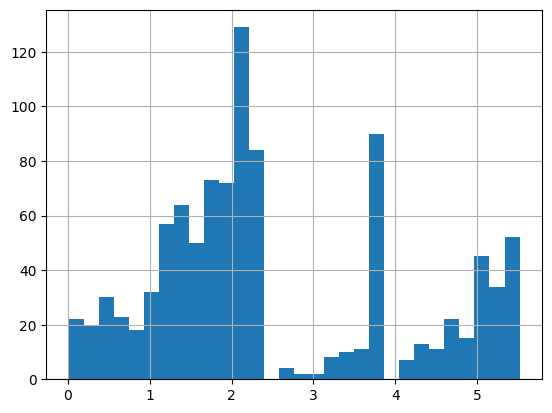

In [101]:
# Dados com transformação logaritmica para PPD
np.log(df_projeto['PPD']).hist(bins=30)
plt.show()

In [102]:
#Substituindo a variável original PPD pelos mesmos dados em escala logaritmica
df_projeto['PPD'+'_log'] = np.log(df_projeto['PPD'])
df_projeto.drop('PPD', axis=1, inplace=True)

In [103]:
df_projeto.columns

Index(['TdT', 'MPO', 'CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'BCR-ABL',
       'PML-RARA', 'NMP22', 'TP53', 'IFN-γ', 'IL-2', 'TNF-α', 'Th1', 'IgG_1',
       'IgA_1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'IgA_2', 'IgM',
       'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'FOXP3', 'classe',
       'CD34_log', 'PPD_log'],
      dtype='object')

> DHR

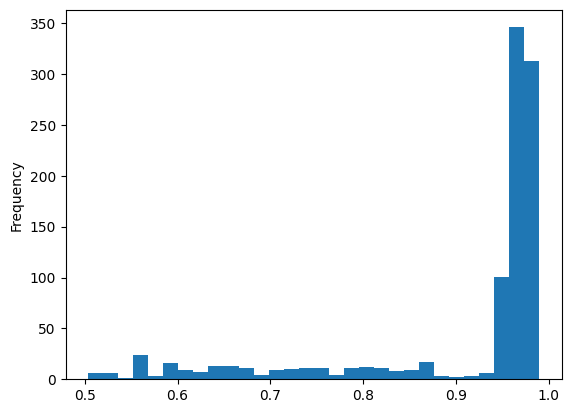

In [104]:
# Dados sem tratamento
df_projeto['DHR'].plot(kind='hist', bins=30)
plt.show()

In [105]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

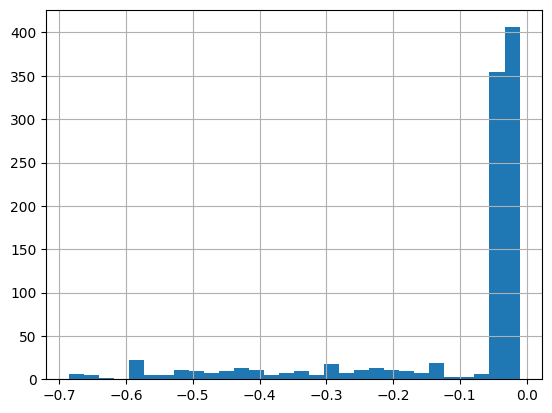

In [106]:
# Dados com transformação logaritmica para DHR
np.log(df_projeto['DHR']).hist(bins=30)
plt.show()

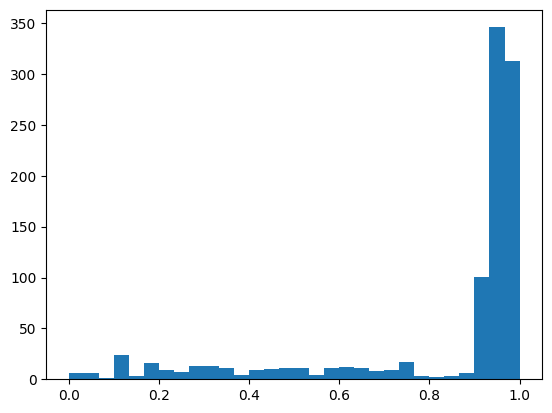

In [107]:
# Dados com normalização
scaler = MinMaxScaler()
dados_padronizados = scaler.fit_transform(df_projeto['DHR'].to_frame())
plt.hist(dados_padronizados, bins=30)
plt.show()

Para esta variável, ao testar todas as possíveis transformações, observei que ela não altera sua distribuição de forma interessante (normalização, padronização nem outras transformaçoes como escala logaritmica ou exponencial). Manterei ela como está.

In [108]:
desc_numericas = df_projeto.describe() #numericas

In [109]:
df_projeto.columns

Index(['TdT', 'MPO', 'CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'BCR-ABL',
       'PML-RARA', 'NMP22', 'TP53', 'IFN-γ', 'IL-2', 'TNF-α', 'Th1', 'IgG_1',
       'IgA_1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'IgA_2', 'IgM',
       'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'FOXP3', 'classe',
       'CD34_log', 'PPD_log'],
      dtype='object')

Neste momento, obtenho o dataset sem missing values, sem constantes e com as vriáveis categóricas em formato booleano

## Valores correlacionados

In [110]:
df_projeto_corr = df_projeto.select_dtypes(include='number').corr()
df_projeto_corr.style.background_gradient(cmap='coolwarm')

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,0.704822,0.693752,0.749989,0.739923,0.019575,-0.073669,-0.463674,-0.459872,0.392757,0.332644,0.396640,-0.438788,-0.393870,-0.319914,-0.284299,0.411213,-0.428957,0.336368,0.353058,0.694465,-0.481603
CD20_1,0.704822,1.000000,0.723823,0.745560,0.744944,0.085606,0.037263,-0.485246,-0.446376,0.333591,0.342020,0.412925,-0.390023,-0.372545,-0.320776,-0.309772,0.421285,-0.376961,0.389664,0.348129,0.703478,-0.536429
CD22,0.693752,0.723823,1.000000,0.729660,0.743305,0.024136,0.031735,-0.478440,-0.469373,0.306929,0.385390,0.424806,-0.431149,-0.360406,-0.353081,-0.350336,0.436630,-0.423453,0.392429,0.368528,0.677013,-0.476597
CD3_1,0.749989,0.745560,0.729660,1.000000,0.721689,0.076472,0.046532,-0.440109,-0.393540,0.383740,0.344464,0.458946,-0.491071,-0.409532,-0.402821,-0.373102,0.459963,-0.462748,0.414994,0.394607,0.684679,-0.460120
CD7,0.739923,0.744944,0.743305,0.721689,1.000000,0.047687,-0.070678,-0.451499,-0.405081,0.397909,0.402259,0.437757,-0.459839,-0.454433,-0.345152,-0.342859,0.475050,-0.462925,0.417713,0.393717,0.704341,-0.445099
NMP22,0.019575,0.085606,0.024136,0.076472,0.047687,1.000000,-0.128236,-0.017829,0.040820,0.020838,-0.032188,0.017963,-0.030100,0.082062,-0.046911,0.031149,0.021818,-0.011133,-0.009637,-0.029106,0.054056,-0.013035
TP53,-0.073669,0.037263,0.031735,0.046532,-0.070678,-0.128236,1.000000,0.015478,0.043840,0.005653,0.064368,0.042058,-0.052677,-0.046841,-0.008685,-0.079854,0.036826,-0.051395,0.126733,-0.022775,0.032242,-0.044942
IFN-γ,-0.463674,-0.485246,-0.478440,-0.440109,-0.451499,-0.017829,0.015478,1.000000,0.768988,0.228079,0.171502,0.188294,-0.230803,-0.220709,-0.216476,-0.172332,0.230160,-0.223720,0.142447,0.208692,-0.456770,0.717074
Th1,-0.459872,-0.446376,-0.469373,-0.393540,-0.405081,0.040820,0.043840,0.768988,1.000000,0.225576,0.238339,0.231082,-0.255171,-0.271027,-0.215567,-0.164699,0.236626,-0.227121,0.170310,0.249999,-0.448771,0.743100
CD3_2,0.392757,0.333591,0.306929,0.383740,0.397909,0.020838,0.005653,0.228079,0.225576,1.000000,0.624374,0.612077,-0.704476,-0.640543,-0.608647,-0.547487,0.702741,-0.687924,0.553625,0.621290,0.321560,0.200421


Definimos que o limite de correlacao sera 0.7

In [111]:
limite = 0.7
corr = df_projeto.corr()
corr[corr > limite].style.background_gradient(cmap='coolwarm')

/tmp/ipykernel_345/1425966841.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_projeto.corr()


,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
TdT,1.000000,1.000000,0.836412,0.857950,0.844706,0.854760,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.823069,nan
MPO,1.000000,1.000000,0.836412,0.857950,0.844706,0.854760,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.823069,nan
CD19_1,0.836412,0.836412,1.000000,0.704822,nan,0.749989,0.739923,0.836412,0.836412,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD20_1,0.857950,0.857950,0.704822,1.000000,0.723823,0.745560,0.744944,0.857950,0.857950,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.703478,nan
CD22,0.844706,0.844706,nan,0.723823,1.000000,0.729660,0.743305,0.844706,0.844706,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD3_1,0.854760,0.854760,0.749989,0.745560,0.729660,1.000000,0.721689,0.854760,0.854760,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD7,0.862957,0.862957,0.739923,0.744944,0.743305,0.721689,1.000000,0.862957,0.862957,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.704341,nan
BCR-ABL,1.000000,1.000000,0.836412,0.857950,0.844706,0.854760,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.823069,nan
PML-RARA,1.000000,1.000000,0.836412,0.857950,0.844706,0.854760,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.823069,nan
NMP22,nan,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


Quero identificar se essas correlacoes estao ligadas a uma classe de resposta especifico - aparentemente não é especifico de uma classe pois os índices de correlacao se mantém uniformes entre as classes

> Valores de correlação para as variáveis considerando a classe _leucemia_

In [112]:
classes = df_projeto['classe'].unique()
c = 0
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'leucemia'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.014358,-0.079371,0.158253,0.128875,0.032222,-0.143915,0.072221,-0.122491,0.371108,-0.070865,0.020611,-0.182574,-0.148062,0.045896,0.144393,-0.111698,-0.108694,-0.154588,0.027256,0.020529,-0.009067
CD20_1,-0.014358,1.000000,0.072677,0.143610,0.041316,0.120877,0.081989,-0.050788,0.183617,0.041291,-0.036886,0.186498,0.102849,-0.037694,0.001417,0.180368,0.135330,0.133826,-0.036615,0.037248,-0.046762,-0.132402
CD22,-0.079371,0.072677,1.000000,0.082191,-0.027753,-0.111528,0.109506,-0.153637,-0.118784,-0.215971,0.084052,0.094664,-0.035047,0.116565,-0.143233,0.074713,0.126407,0.045360,0.072582,0.046300,-0.177927,-0.034859
CD3_1,0.158253,0.143610,0.082191,1.000000,0.078461,0.093752,0.106688,-0.224397,0.124786,0.111175,-0.123776,0.031265,-0.018987,-0.053987,0.036545,0.029961,0.036199,0.012663,-0.148936,-0.129408,-0.055833,-0.115149
CD7,0.128875,0.041316,-0.027753,0.078461,1.000000,0.042724,-0.178642,-0.020249,0.191664,0.062459,0.090609,0.039553,-0.016377,-0.262260,0.140482,0.003834,-0.129198,-0.074074,-0.054067,0.080622,0.081276,0.201563
NMP22,0.032222,0.120877,-0.111528,0.093752,0.042724,1.000000,-0.121451,-0.012797,-0.005209,0.086836,-0.031824,-0.028079,0.070805,0.133071,-0.117748,0.098306,0.020707,0.053396,-0.086667,-0.185592,0.012887,0.083242
TP53,-0.143915,0.081989,0.109506,0.106688,-0.178642,-0.121451,1.000000,-0.156875,0.090906,-0.172863,0.157454,-0.024106,-0.115094,0.013210,-0.011108,-0.057496,-0.141832,-0.007025,0.288417,-0.091505,0.020467,-0.147314
IFN-γ,0.072221,-0.050788,-0.153637,-0.224397,-0.020249,-0.012797,-0.156875,1.000000,-0.126690,-0.026483,0.107715,0.095257,-0.133663,0.040647,-0.091170,0.026188,0.021931,-0.082169,-0.000390,-0.030669,-0.079476,-0.300750
Th1,-0.122491,0.183617,-0.118784,0.124786,0.191664,-0.005209,0.090906,-0.126690,1.000000,-0.152534,0.073426,0.012239,-0.032564,-0.189021,0.011998,0.131612,-0.096467,0.238759,0.069916,-0.022687,0.123985,0.110255
CD3_2,0.371108,0.041291,-0.215971,0.111175,0.062459,0.086836,-0.172863,-0.026483,-0.152534,1.000000,0.089881,-0.058736,0.033415,0.006390,-0.038076,0.167173,-0.081756,0.061823,-0.197464,-0.077295,0.084469,-0.018583


> Valores de correlação para as variáveis considerando a classe _cancer_

In [113]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'cancer'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.067574,-0.013335,0.134647,0.136151,-0.010260,-0.177768,0.006924,-0.046167,0.304029,0.030261,-0.078645,-0.166887,-0.134953,0.089441,0.184134,-0.050147,-0.234417,-0.176623,-0.006341,0.022398,-0.110509
CD20_1,-0.067574,1.000000,-0.050244,0.101532,0.020897,0.144327,0.132265,0.016389,0.135753,0.006806,-0.057071,0.033140,0.037968,0.043114,0.011885,0.037962,0.042424,0.189006,0.080895,-0.004119,0.045425,-0.342517
CD22,-0.013335,-0.050244,1.000000,0.012869,0.169952,0.008716,0.079996,-0.047693,-0.229483,-0.130829,0.130630,0.071398,-0.091643,0.100808,-0.007321,-0.067586,0.059600,-0.083569,-0.006567,-0.020754,-0.144896,0.029091
CD3_1,0.134647,0.101532,0.012869,1.000000,-0.106984,0.065813,0.178560,-0.093883,0.030546,0.041512,-0.088588,-0.030924,-0.055768,0.048683,0.005704,-0.039963,0.039494,0.034032,-0.100603,-0.045099,-0.124625,-0.345685
CD7,0.136151,0.020897,0.169952,-0.106984,1.000000,-0.003181,-0.179922,0.084231,0.079378,0.080216,0.166694,-0.048679,-0.056367,-0.276591,0.118432,0.100519,-0.022278,-0.152242,-0.027632,0.050338,0.058437,0.020622
NMP22,-0.010260,0.144327,0.008716,0.065813,-0.003181,1.000000,-0.109352,-0.027280,-0.071191,-0.006658,-0.003775,-0.184773,-0.014915,0.276175,-0.079239,0.075614,-0.037593,-0.060793,-0.152325,-0.148093,0.047013,-0.090194
TP53,-0.177768,0.132265,0.079996,0.178560,-0.179922,-0.109352,1.000000,-0.031944,0.141083,-0.069160,0.089061,0.037599,-0.054298,-0.006368,-0.034115,-0.089637,-0.122213,0.137627,0.155922,-0.065171,-0.104490,-0.164985
IFN-γ,0.006924,0.016389,-0.047693,-0.093883,0.084231,-0.027280,-0.031944,1.000000,-0.038850,-0.151633,0.120695,-0.004331,-0.097557,0.162048,-0.108550,0.004664,0.172770,-0.151084,-0.043333,-0.175468,0.060344,-0.147361
Th1,-0.046167,0.135753,-0.229483,0.030546,0.079378,-0.071191,0.141083,-0.038850,1.000000,-0.120669,0.104859,0.128068,-0.028705,-0.204777,-0.055844,0.055130,-0.065764,0.211706,0.125173,0.079729,0.065732,-0.141862
CD3_2,0.304029,0.006806,-0.130829,0.041512,0.080216,-0.006658,-0.069160,-0.151633,-0.120669,1.000000,0.192710,-0.036559,0.010911,-0.015267,-0.044306,-0.005716,-0.186652,0.011442,-0.042458,-0.083797,0.149716,0.034479


> Valores de correlação para as variáveis considerando a classe _BCG_

In [114]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'BCG'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.037232,-0.072015,0.122279,-0.104264,-0.105347,-0.170911,0.029404,-0.089444,-0.137217,-0.151996,0.126080,-0.261869,0.089017,-0.274752,0.076222,-0.119898,0.045358,0.101074,-0.010486,0.111854,-0.068396
CD20_1,-0.037232,1.000000,-0.130037,-0.063643,0.194446,-0.021883,0.105478,0.043067,0.038650,0.084813,0.023240,-0.159059,0.090978,-0.114392,0.096534,0.113379,0.130719,-0.027579,0.023260,-0.048004,-0.068484,-0.015093
CD22,-0.072015,-0.130037,1.000000,-0.065375,0.037547,0.022839,0.043444,-0.083497,-0.043403,0.207257,0.075659,0.062213,-0.187068,0.060911,-0.045911,-0.087248,0.073776,-0.031870,-0.009421,0.241622,-0.032579,-0.064402
CD3_1,0.122279,-0.063643,-0.065375,1.000000,-0.110502,0.101577,0.063234,0.098413,0.115734,-0.003141,-0.259928,0.045964,-0.047347,-0.017061,-0.300866,0.059121,-0.137496,-0.034326,0.079616,0.064567,-0.025306,-0.063659
CD7,-0.104264,0.194446,0.037547,-0.110502,1.000000,0.007173,-0.059451,-0.014661,0.074234,0.094625,-0.045738,-0.028601,0.007325,-0.186502,-0.075331,0.145242,0.031872,-0.119907,0.051714,-0.038399,0.013484,0.013706
NMP22,-0.105347,-0.021883,0.022839,0.101577,0.007173,1.000000,-0.082275,0.009419,0.241419,-0.033317,-0.228629,0.170228,0.075543,0.130366,0.039059,0.083508,-0.036528,0.042855,0.130127,0.075287,-0.020769,0.036874
TP53,-0.170911,0.105478,0.043444,0.063234,-0.059451,-0.082275,1.000000,-0.092809,-0.022247,0.006502,-0.036484,0.021643,0.008837,0.047273,0.153049,-0.114853,0.126353,-0.015239,0.006958,-0.137548,0.097667,-0.194360
IFN-γ,0.029404,0.043067,-0.083497,0.098413,-0.014661,0.009419,-0.092809,1.000000,0.034105,-0.081990,-0.216645,-0.028346,0.009316,0.035284,0.037932,0.009511,-0.140982,-0.064373,-0.045934,-0.117157,0.018380,-0.081548
Th1,-0.089444,0.038650,-0.043403,0.115734,0.074234,0.241419,-0.022247,0.034105,1.000000,-0.091817,0.136023,0.173322,-0.068023,-0.022788,0.052248,0.074309,0.127598,-0.206249,-0.036385,-0.028234,-0.119691,0.105130
CD3_2,-0.137217,0.084813,0.207257,-0.003141,0.094625,-0.033317,0.006502,-0.081990,-0.091817,1.000000,0.052178,-0.079545,-0.307846,0.157972,-0.141143,-0.064900,0.010653,-0.233116,0.056941,0.096740,-0.045887,-0.077665


> Valores de correlação para as variáveis considerando a classe _imunodeficiência_

In [115]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'imunodeficiencia'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.005338,0.007025,0.156493,-0.072970,-0.133156,0.072632,-0.230490,0.032773,-0.112258,-0.027546,0.044167,-0.023671,-0.006589,0.119829,0.105234,-0.052151,0.022382,0.079522,0.087337,-0.046650,0.082871
CD20_1,-0.005338,1.000000,0.007095,-0.193553,-0.188952,0.108379,0.055700,-0.068092,-0.252928,-0.104182,0.168779,-0.205549,0.205831,0.059682,-0.007467,-0.047350,-0.054973,0.220661,0.026257,-0.171370,-0.015533,-0.100720
CD22,0.007025,0.007095,1.000000,0.045253,-0.052965,0.119154,0.069830,0.097024,0.004955,0.072832,-0.094648,-0.097723,-0.039088,-0.105576,-0.028703,0.096226,0.121158,-0.090231,0.027139,-0.028616,0.132192,-0.119364
CD3_1,0.156493,-0.193553,0.045253,1.000000,-0.121517,0.067960,0.055722,-0.099319,-0.028073,-0.059242,-0.059514,0.139385,-0.251469,0.179763,-0.057172,0.157316,-0.099369,-0.046574,0.198491,0.063193,-0.079767,0.206568
CD7,-0.072970,-0.188952,-0.052965,-0.121517,1.000000,0.070938,-0.111218,-0.040973,0.145307,0.259532,-0.001133,0.054576,-0.075597,0.064663,0.039351,0.135454,0.127668,0.034477,0.160523,-0.045512,-0.151924,-0.013331
NMP22,-0.133156,0.108379,0.119154,0.067960,0.070938,1.000000,-0.215441,-0.021926,0.173028,-0.086720,-0.042985,0.037047,-0.096201,0.240067,0.062451,0.033602,-0.019300,0.066372,-0.107282,-0.090879,0.111636,-0.007919
TP53,0.072632,0.055700,0.069830,0.055722,-0.111218,-0.215441,1.000000,0.082825,-0.192743,0.089833,-0.001478,0.047020,-0.026521,-0.139674,-0.113354,0.043333,0.020811,-0.164983,0.191645,-0.075121,0.178225,-0.130001
IFN-γ,-0.230490,-0.068092,0.097024,-0.099319,-0.040973,-0.021926,0.082825,1.000000,0.133452,0.119366,-0.018957,0.080065,-0.044582,0.134859,-0.102696,0.055565,0.108289,-0.041489,0.054181,-0.016206,-0.067437,-0.014952
Th1,0.032773,-0.252928,0.004955,-0.028073,0.145307,0.173028,-0.192743,0.133452,1.000000,-0.137372,0.031752,0.121686,-0.187157,0.095973,0.002017,0.026948,-0.040963,-0.028619,-0.078120,0.040043,-0.097954,0.035287
CD3_2,-0.112258,-0.104182,0.072832,-0.059242,0.259532,-0.086720,0.089833,0.119366,-0.137372,1.000000,0.103485,0.032429,-0.072480,-0.010968,-0.186800,0.031736,0.181026,-0.135103,0.041665,0.036079,-0.157856,-0.052810


In [116]:
col_baixa_corr = list(corr[corr < limite].columns)

In [117]:
df_baixa_corr = df_projeto[col_baixa_corr]

In [118]:
df_baixa_corr

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,...,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
0,0.471228,0.398837,0.233216,0.329756,0.417118,9,0.072077,0.236097,1219,4777.735596,...,949.930723,315.361867,247.894093,396.067195,0.967908,93,230,42,-2.125596,0.588027
1,0.292042,0.370941,0.253135,0.340733,0.350616,7,0.099415,0.195858,1431,2728.722124,...,1078.800779,161.418609,213.416161,361.036864,0.972741,135,351,64,-2.185510,3.714128
2,0.372872,0.257518,0.451758,0.487803,0.399385,4,0.206770,0.210132,876,3496.556667,...,1265.581855,296.797741,296.635039,244.867766,0.971384,69,238,44,-1.739342,2.057824
3,0.469943,0.495637,0.351360,0.332752,0.487439,4,0.087026,0.111679,1350,4422.935251,...,1515.262148,89.518480,564.401375,530.296010,0.962450,90,262,41,-2.544432,2.230950
4,0.349343,0.381742,0.220939,0.479723,0.453555,8,0.154890,0.238945,647,3021.382901,...,1142.025578,215.929093,238.791009,152.442218,0.955740,76,209,46,-2.795526,0.083765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.393222,0.458290,0.346061,0.492897,0.382239,9,0.208846,0.187005,1411,4057.575204,...,942.280083,233.855081,255.509749,459.141490,0.966046,118,219,54,-1.789109,0.756665
996,0.193642,0.177386,0.121604,0.184222,0.252370,7,0.135599,0.539736,3317,4844.952962,...,726.591600,153.752428,188.390556,510.571071,0.957331,113,283,77,-4.588500,5.410892
997,0.326550,0.380776,0.316968,0.457663,0.484900,8,0.010049,0.193008,1340,4444.912410,...,1175.938546,129.768967,337.514274,489.258714,0.966584,113,180,46,-3.011878,2.160236
998,0.142724,0.103813,0.127491,0.301079,0.206177,2,0.090487,0.542345,2461,3402.061077,...,1084.735070,192.912761,325.206792,527.798002,0.954264,133,207,75,-6.869732,4.441393


In [119]:
# Greedily pick 1 features using backward selection to remove features until only 1 remains
#modelo de classificacao com multiplas arvores de decisao - define a coluna mais importante para classificacao
knn = RandomForestClassifier()

#aplica uma selecao de variaveis sequencial. Cria uma RF com um conjunto total, depois ele tira uma das variaveis e roda novamente, ate que 
#permaneca um numero minimo de variaveis (n_features_to_select)
sfs = SequentialFeatureSelector(knn, n_features_to_select=1, direction='backward')

X = df_projeto[colunas]
y = df_projeto['classe']

#fit transform é a aplicacao do sfs!
X_selected = sfs.fit_transform(X, y)
X_selected.shape

NameError: name 'colunas' is not defined

In [ ]:
X_selected[:5]

array([[0.41711815],
       [0.35061612],
       [0.39938524],
       [0.48743866],
       [0.45355496]])

In [ ]:
df_projeto['correlatas'] = X_selected
df_projeto.drop(colunas, axis=1, inplace=True)

df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CD34        1000 non-null   float64
 1   NMP22       1000 non-null   int64  
 2   TP53        1000 non-null   float64
 3   IFN-γ       1000 non-null   float64
 4   IL-2        1000 non-null   object 
 5   TNF-α       1000 non-null   object 
 6   Th1         1000 non-null   int64  
 7   IgG_1       1000 non-null   object 
 8   IgA_1       1000 non-null   object 
 9   CD3_2       1000 non-null   float64
 10  CD4         1000 non-null   float64
 11  CD8         1000 non-null   float64
 12  CD19_2      1000 non-null   float64
 13  CD20_2      1000 non-null   float64
 14  IgA_2       1000 non-null   object 
 15  IgM         1000 non-null   object 
 16  CD16        1000 non-null   float64
 17  CD56        1000 non-null   float64
 18  DHR         1000 non-null   float64
 19  CH50        1000 non-null   

In [ ]:
corr = df_projeto.select_dtypes(include='number').corr()
corr.style.background_gradient(cmap='coolwarm')

,CD34,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log,correlatas
CD34,1.000000,0.017514,-0.029565,-0.447072,-0.404503,0.335673,0.364862,0.364315,-0.365406,-0.341087,-0.291381,-0.293282,0.390118,-0.386217,0.286640,0.338805,-0.425739,0.701262
NMP22,0.017514,1.000000,-0.128236,-0.017829,0.040820,0.020838,-0.032188,0.017963,-0.030100,0.082062,-0.046911,0.031149,0.021818,-0.011133,-0.009637,-0.029106,0.002296,0.047687
TP53,-0.029565,-0.128236,1.000000,0.015478,0.043840,0.005653,0.064368,0.042058,-0.052677,-0.046841,-0.008685,-0.079854,0.036826,-0.051395,0.126733,-0.022775,-0.043580,-0.070678
IFN-γ,-0.447072,-0.017829,0.015478,1.000000,0.768988,0.228079,0.171502,0.188294,-0.230803,-0.220709,-0.216476,-0.172332,0.230160,-0.223720,0.142447,0.208692,0.739156,-0.451499
Th1,-0.404503,0.040820,0.043840,0.768988,1.000000,0.225576,0.238339,0.231082,-0.255171,-0.271027,-0.215567,-0.164699,0.236626,-0.227121,0.170310,0.249999,0.760035,-0.405081
CD3_2,0.335673,0.020838,0.005653,0.228079,0.225576,1.000000,0.624374,0.612077,-0.704476,-0.640543,-0.608647,-0.547487,0.702741,-0.687924,0.553625,0.621290,0.229913,0.397909
CD4,0.364862,-0.032188,0.064368,0.171502,0.238339,0.624374,1.000000,0.582321,-0.648975,-0.618117,-0.529087,-0.530940,0.675313,-0.628334,0.540265,0.549666,0.186511,0.402259
CD8,0.364315,0.017963,0.042058,0.188294,0.231082,0.612077,0.582321,1.000000,-0.692105,-0.683655,-0.605119,-0.592197,0.735331,-0.688547,0.587506,0.659399,0.177770,0.437757
CD19_2,-0.365406,-0.030100,-0.052677,-0.230803,-0.255171,-0.704476,-0.648975,-0.692105,1.000000,0.711120,0.659169,0.639575,-0.738941,0.741264,-0.661476,-0.697101,-0.207681,-0.459839
CD20_2,-0.341087,0.082062,-0.046841,-0.220709,-0.271027,-0.640543,-0.618117,-0.683655,0.711120,1.000000,0.577459,0.545103,-0.722814,0.732727,-0.606822,-0.706012,-0.244857,-0.454433


In [ ]:
corr = df_projeto.corr()
limite = 0.8
corr[corr > limite].style.background_gradient(cmap='coolwarm')

/tmp/ipykernel_34357/2795813377.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_projeto.corr()


,CD34,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log,correlatas
CD34,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
NMP22,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
TP53,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
IFN-γ,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Th1,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD3_2,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD4,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD8,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD19_2,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD20_2,nan,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe,PPD_log,correlatas
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,leucemia,0.588027,0.417118
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,leucemia,2.400111,0.350616
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,leucemia,2.057824,0.399385
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,leucemia,2.230950,0.487439
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,leucemia,0.083765,0.453555


In [ ]:
colunas = list(df_projeto.columns[:-3])
colunas.append('PPD_log')
colunas.append('correlatas')
colunas.append('classe')

df_projeto = df_projeto[colunas]
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,PPD_log,correlatas,classe
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,0.588027,0.417118,leucemia
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,2.400111,0.350616,leucemia
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,2.057824,0.399385,leucemia
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,2.230950,0.487439,leucemia
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,0.083765,0.453555,leucemia


In [ ]:
# df_projeto.to_csv("./data/07_aula_07_df_projeto_estruturada.csv", index=False)

# dump(df_projeto, "./data/07_aula_07_df_projeto_estruturada")

df_projeto = load("./data/07_aula_07_df_projeto_estruturada")
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,PPD_log,correlatas,classe
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,0.588027,0.417118,leucemia
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,2.400111,0.350616,leucemia
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,2.057824,0.399385,leucemia
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,2.230950,0.487439,leucemia
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,0.083765,0.453555,leucemia


In [ ]:
num_columns = df_projeto.select_dtypes(include='number').columns
eixos_graficos = [
    [5,2],
    [3,16],
    [7,5],
    [17,16],
]
num_columns

Index(['CD34', 'NMP22', 'TP53', 'IFN-γ', 'Th1', 'CD3_2', 'CD4', 'CD8',
       'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4',
       'PPD_log', 'correlatas'],
      dtype='object')

## Alterando categóricas para booleanas

In [ ]:
desc_cat = df_projeto.describe(include = 'object') #categorical and boolean

In [ ]:
# Convertendo variáveis categóricas em variáveis dummy - total 40 colunas
pd.get_dummies(df_projeto, columns=['IL-2', 'TNF-α','IgA_1','IgA_2','IgM', 'FOXP3']).head()

,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,NMP22,...,TNF-α_Alto,TNF-α_Baixo,IgA_1_Alto,IgA_1_Baixo,IgA_2_Alto,IgA_2_Baixo,IgM_Alto,IgM_Baixo,FOXP3_Alterado,FOXP3_Normal
0,True,True,0.471228,0.398837,0.233216,0.329756,0.417118,True,True,9,...,0,1,0,1,1,0,1,0,0,1
1,True,True,0.292042,0.370941,0.253135,0.340733,0.350616,True,True,7,...,0,1,0,1,1,0,1,0,0,1
2,True,True,0.372872,0.257518,0.451758,0.487803,0.399385,True,True,4,...,0,1,0,1,1,0,1,0,0,1
3,True,True,0.469943,0.495637,0.351360,0.332752,0.487439,True,True,4,...,0,1,0,1,1,0,1,0,0,1
4,True,True,0.349343,0.381742,0.220939,0.479723,0.453555,True,True,8,...,0,1,0,1,1,0,1,0,0,1
